In [1]:
import pandas as pd
import numpy as np

In [2]:
eth = pd.read_csv("ethereum_wallets.csv")
poly = pd.read_csv("polygon_wallets.csv")

df = pd.concat([eth, poly], ignore_index=True)

In [3]:
df.head()
df.shape
df.columns
df.dtypes

wallet                str
tx_count            int64
total_volume      float64
avg_tx_value      float64
active_days         int64
protocols_used      int64
chain                 str
dtype: object

In [4]:
# remove duplicates
df = df.drop_duplicates(subset=['wallet','chain'])

# ensure numeric
numeric_cols = ['tx_count','total_volume','avg_tx_value','active_days','protocols_used']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# remove invalid rows
df = df[
    (df['tx_count'] > 0) &
    (df['total_volume'] >= 0) &
    (df['avg_tx_value'] >= 0) &
    (df['active_days'] > 0) &
    (df['protocols_used'] > 0)
]

df = df.reset_index(drop=True)

In [5]:
# remove duplicates
df = df.drop_duplicates(subset=['wallet','chain'])

# ensure numeric
numeric_cols = ['tx_count','total_volume','avg_tx_value','active_days','protocols_used']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# remove invalid rows
df = df[
    (df['tx_count'] > 0) &
    (df['total_volume'] >= 0) &
    (df['avg_tx_value'] >= 0) &
    (df['active_days'] > 0) &
    (df['protocols_used'] > 0)
]

df = df.reset_index(drop=True)

In [6]:
df_model = df.drop(columns=['wallet'])

# encode chain
df_model = pd.get_dummies(df_model, columns=['chain'], drop_first=True)

In [7]:
df_model['tx_count'] = np.log1p(df_model['tx_count'])
df_model['total_volume'] = np.log1p(df_model['total_volume'])
df_model['avg_tx_value'] = np.log1p(df_model['avg_tx_value'])
df_model['protocols_used'] = np.log1p(df_model['protocols_used'])

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

In [ ]:
!pip install scikit-learn

In [ ]:
inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [ ]:
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
!pip install scikit-learn

In [ ]:
import sys
print(sys.executable)

In [1]:
import pandas as pd

eth = pd.read_csv("ethereum_wallets.csv")
poly = pd.read_csv("polygon_wallets.csv")

In [1]:
df = pd.concat([eth, poly], ignore_index=True)
print(df.shape)
df.head()

NameError: name 'pd' is not defined

In [2]:
import pandas as pd

eth = pd.read_csv("ethereum_wallets.csv")
poly = pd.read_csv("polygon_wallets.csv")

In [3]:
df = pd.concat([eth, poly], ignore_index=True)
print(df.shape)
df.head()

(2000, 7)


,wallet,tx_count,total_volume,avg_tx_value,active_days,protocols_used,chain
0,0xee845948e6806d12e966137caa07d49bbe632fe3,13415,47760.183490,3.560207,90,232,ethereum
1,0x8afaacdfaab4a6938a2da1705a6a2679bfc74e63,143767,7.588570,0.000053,90,119702,ethereum
2,0x3980daa7eaad0b7e0c53cfc5c2760037270da54d,42235,4.999385,0.000118,90,26,ethereum
3,0xc83b29f780143fcbc44737e6ea9ff43ae39b917c,9475,1.000000,0.000106,90,2,ethereum
4,0xf6f5d7b95b63b5c9a96037ba3264ea8fc663e732,16,0.001588,0.000099,58,3,ethereum


In [4]:
df = df.drop_duplicates()

In [5]:
df.isnull().sum()

wallet            0
tx_count          0
total_volume      0
avg_tx_value      0
active_days       0
protocols_used    0
chain             0
dtype: int64

In [6]:
numeric_cols = ['tx_count', 'total_volume', 'avg_tx_value', 'active_days', 'protocols_used']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [7]:
df = df[df['tx_count'] > 0]
df = df[df['total_volume'] >= 0]

In [8]:
df['tx_per_day'] = df['tx_count'] / df['active_days']
df['volume_per_tx'] = df['total_volume'] / df['tx_count']

In [9]:
df_model = df.copy()

# Drop non-numeric
df_model = df_model.drop(columns=['wallet'])

# Encode chain
df_model = pd.get_dummies(df_model, columns=['chain'], drop_first=True)

In [10]:
import numpy as np

log_cols = ['tx_count', 'total_volume', 'avg_tx_value', 'protocols_used', 'tx_per_day', 'volume_per_tx']

for col in log_cols:
    df_model[col] = np.log1p(df_model[col])

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [14]:
cluster_summary = df.groupby('cluster').mean()
print(cluster_summary)

TypeError: dtype 'str' does not support operation 'mean'

In [15]:
cluster_summary = df.groupby('cluster').mean(numeric_only=True)
print(cluster_summary)

             tx_count  total_volume  avg_tx_value  active_days  \
cluster                                                          
0           31.935540      1.042015      0.057963    14.728223   
1        17705.402560  14374.967507     27.451841    80.668563   
2          108.049793      3.726774      0.065500    75.052559   

         protocols_used  tx_per_day  volume_per_tx  
cluster                                             
0              5.831010    4.304278       0.057963  
1            632.163585  209.614047      27.451841  
2             14.040111    1.389315       0.065500  


In [16]:
cluster_summary

,tx_count,total_volume,avg_tx_value,active_days,protocols_used,tx_per_day,volume_per_tx
cluster,,,,,,,
0,31.935540,1.042015,0.057963,14.728223,5.831010,4.304278,0.057963
1,17705.402560,14374.967507,27.451841,80.668563,632.163585,209.614047,27.451841
2,108.049793,3.726774,0.065500,75.052559,14.040111,1.389315,0.065500


In [17]:
df['volume_per_tx'] = df['total_volume'] / df['tx_count']

In [18]:
import numpy as np
df['log_tx_count'] = np.log1p(df['tx_count'])
df['log_volume'] = np.log1p(df['total_volume'])

In [19]:
features = [
 'tx_count',
 'total_volume',
 'avg_tx_value',
 'active_days',
 'protocols_used',
 'tx_per_day'
]

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

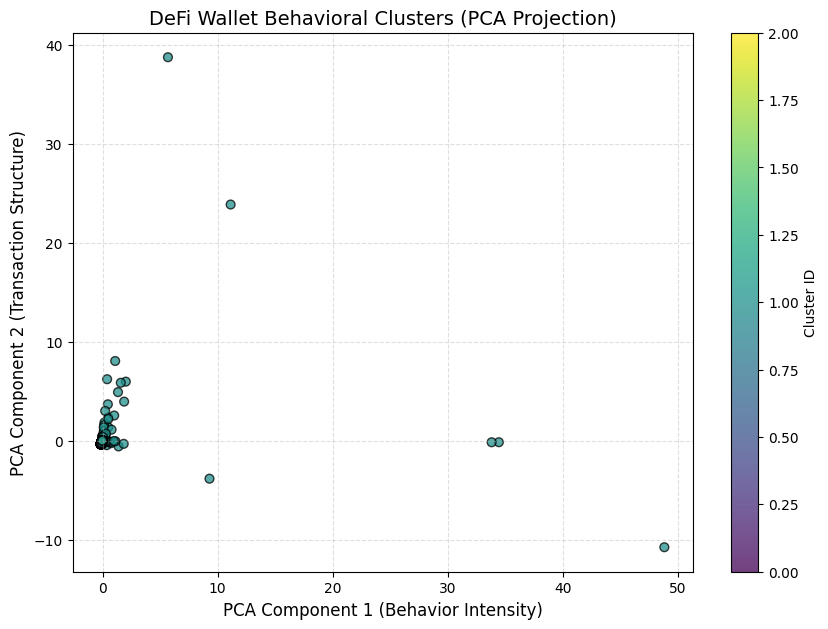

In [21]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create figure
plt.figure(figsize=(10, 7))

# Scatter plot
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.75,
    s=40,
    edgecolors='k'
)

# Labels & title
plt.xlabel("PCA Component 1 (Behavior Intensity)", fontsize=12)
plt.ylabel("PCA Component 2 (Transaction Structure)", fontsize=12)
plt.title("DeFi Wallet Behavioral Clusters (PCA Projection)", fontsize=14)

# Grid for readability
plt.grid(True, linestyle='--', alpha=0.4)

# Legend-style color reference
cbar = plt.colorbar(scatter)
cbar.set_label("Cluster ID")

# Show plot
plt.show()

In [22]:
from sklearn.ensemble import IsolationForest

# Train model
iso = IsolationForest(
    contamination=0.05,   # assumes 5% anomalous wallets
    random_state=42
)

# Fit + predict
df['anomaly_score'] = iso.fit_predict(X_scaled)

# Convert output to readable labels
df['anomaly_label'] = df['anomaly_score'].map({
    1: "Normal Wallet",
    -1: "Anomalous Wallet"
})

In [23]:
print(df['anomaly_label'].value_counts())

anomaly_label
Normal Wallet       1901
Anomalous Wallet      99
Name: count, dtype: int64


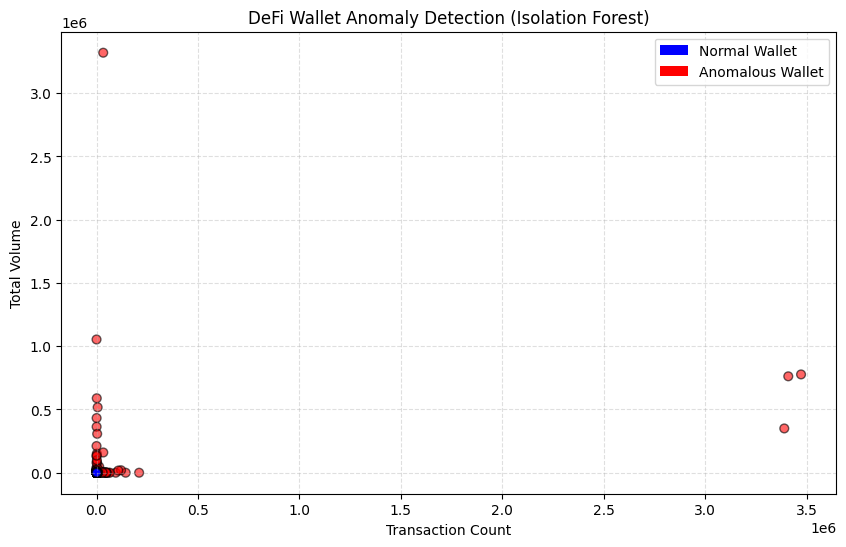

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Map colors properly
color_map = {
    "Normal Wallet": "blue",
    "Anomalous Wallet": "red"
}

colors = df['anomaly_label'].map(color_map)

# Scatter plot
plt.scatter(
    df['tx_count'],
    df['total_volume'],
    c=colors,
    alpha=0.6,
    edgecolors='k',
    s=40
)

# Labels
plt.xlabel("Transaction Count")
plt.ylabel("Total Volume")
plt.title("DeFi Wallet Anomaly Detection (Isolation Forest)")

# Custom legend (IMPORTANT FIX)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', label='Normal Wallet'),
    Patch(facecolor='red', label='Anomalous Wallet')
]

plt.legend(handles=legend_elements)

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

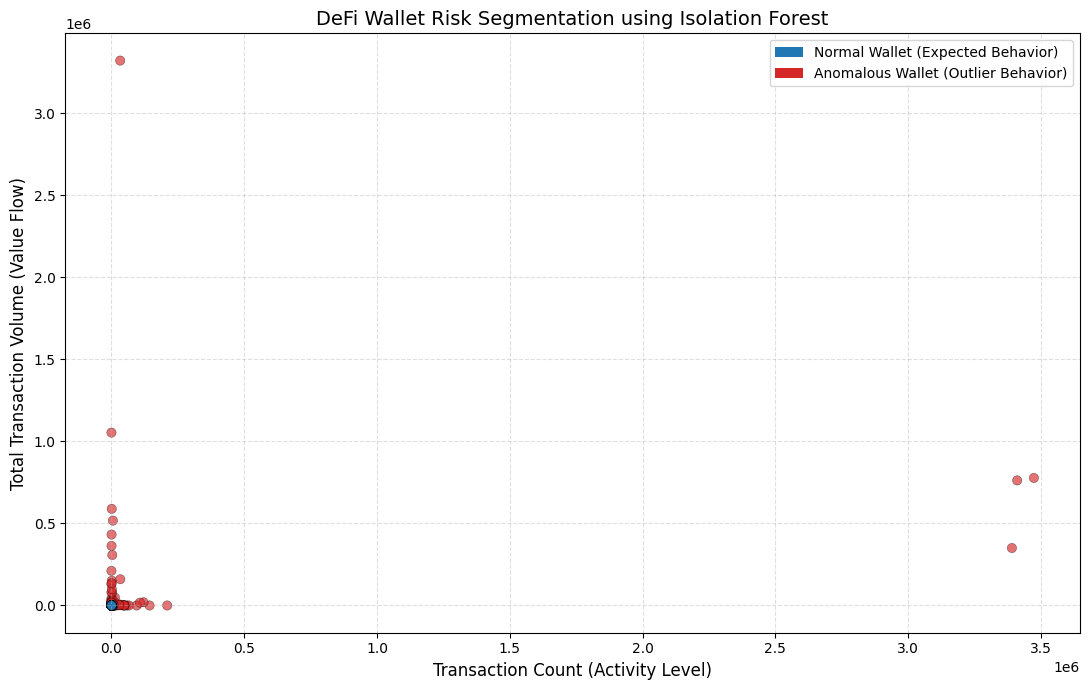

In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.figure(figsize=(11,7))

# Color mapping (clear semantic meaning)
color_map = {
    "Normal Wallet": "#1f77b4",      # blue (standard)
    "Anomalous Wallet": "#d62728"    # red (risk)
}

colors = df['anomaly_label'].map(color_map)

# Scatter plot (clean + readable)
plt.scatter(
    df['tx_count'],
    df['total_volume'],
    c=colors,
    alpha=0.65,
    s=45,
    edgecolors='black',
    linewidths=0.3
)

# Axis labels (more descriptive)
plt.xlabel("Transaction Count (Activity Level)", fontsize=12)
plt.ylabel("Total Transaction Volume (Value Flow)", fontsize=12)
plt.title("DeFi Wallet Risk Segmentation using Isolation Forest", fontsize=14)

# Custom legend (correct + professional)
legend_elements = [
    Patch(facecolor='#1f77b4', label='Normal Wallet (Expected Behavior)'),
    Patch(facecolor='#d62728', label='Anomalous Wallet (Outlier Behavior)')
]

plt.legend(handles=legend_elements, loc='best')

# Grid for structure readability
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

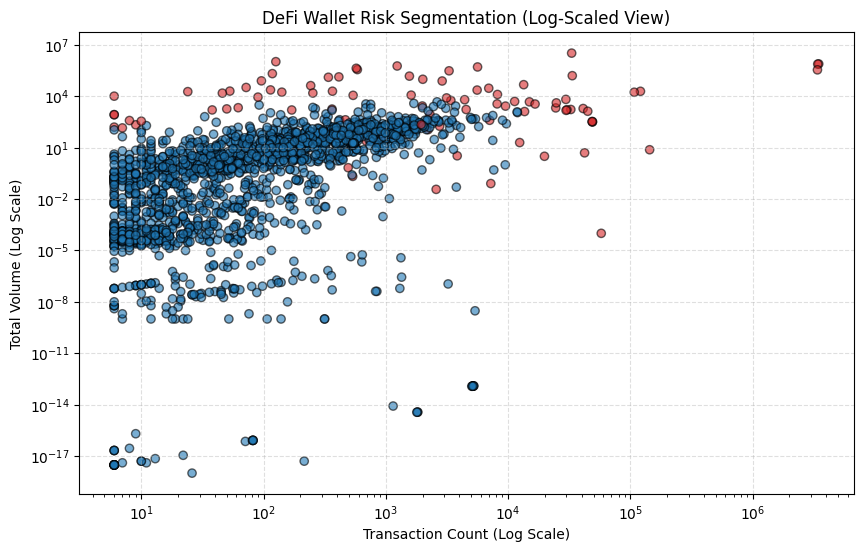

In [26]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['tx_count'],
    df['total_volume'],
    c=colors,
    alpha=0.6,
    edgecolors='k'
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Transaction Count (Log Scale)")
plt.ylabel("Total Volume (Log Scale)")

plt.title("DeFi Wallet Risk Segmentation (Log-Scaled View)")

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

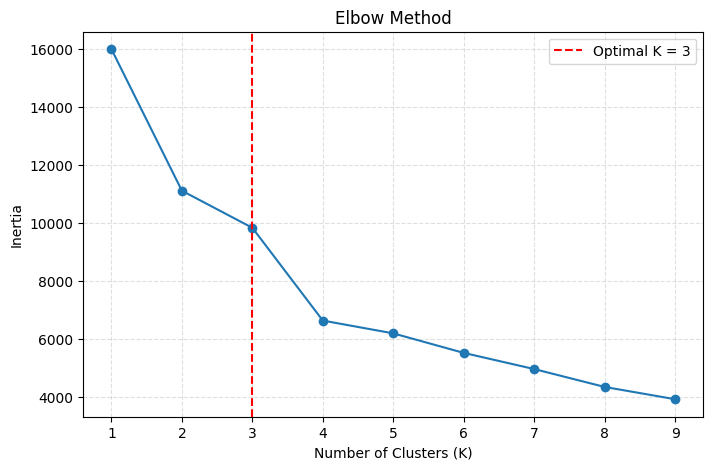

In [27]:
plt.figure(figsize=(8,5))

# Line plot
plt.plot(K_range, inertia, marker='o')

# Highlight optimal K
optimal_k = 3
plt.axvline(x=optimal_k, linestyle='--', color='red', label='Optimal K = 3')

# Labels
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Grid for readability
plt.grid(True, linestyle='--', alpha=0.4)

# Legend
plt.legend()

# Save figure
import os
os.makedirs("visuals", exist_ok=True)
plt.savefig("visuals/elbow_method.png", dpi=300, bbox_inches='tight')

plt.show()

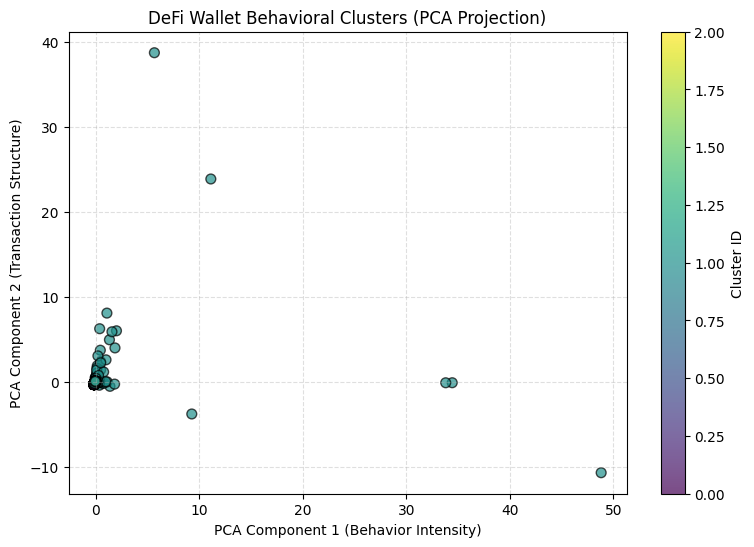

In [28]:
plt.figure(figsize=(9,6))

# Scatter plot
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='k',
    s=50
)

# Axis labels with meaning
plt.xlabel("PCA Component 1 (Behavior Intensity)")
plt.ylabel("PCA Component 2 (Transaction Structure)")

# Title
plt.title("DeFi Wallet Behavioral Clusters (PCA Projection)")

# Colorbar (VERY IMPORTANT)
cbar = plt.colorbar(scatter)
cbar.set_label("Cluster ID")

# Grid for readability
plt.grid(True, linestyle='--', alpha=0.4)

# Save figure
import os
os.makedirs("visuals", exist_ok=True)
plt.savefig("visuals/pca_clusters.png", dpi=300, bbox_inches='tight')

plt.show()

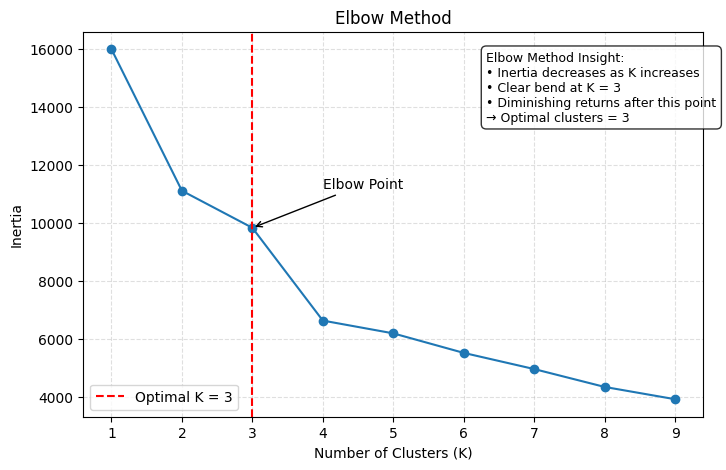

In [29]:
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker='o')

optimal_k = 3
plt.axvline(x=optimal_k, linestyle='--', color='red', label='Optimal K = 3')

# 🔥 Arrow to elbow
plt.annotate(
    "Elbow Point",
    xy=(3, inertia[2]),
    xytext=(4, max(inertia)*0.7),
    arrowprops=dict(facecolor='black', arrowstyle='->')
)

# 🔥 Insight box (clean version of your paragraph)
insight_text = (
    "Elbow Method Insight:\n"
    "• Inertia decreases as K increases\n"
    "• Clear bend at K = 3\n"
    "• Diminishing returns after this point\n"
    "→ Optimal clusters = 3"
)

plt.text(
    0.65, 0.95, insight_text,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8)
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.savefig("visuals/elbow_method.png", dpi=300, bbox_inches='tight')
plt.show()

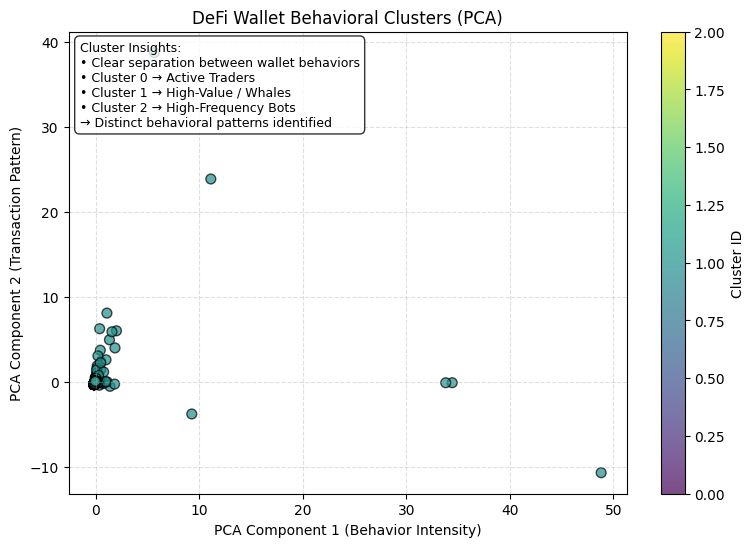

In [30]:
plt.figure(figsize=(9,6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='k',
    s=50
)

# Labels
plt.xlabel("PCA Component 1 (Behavior Intensity)")
plt.ylabel("PCA Component 2 (Transaction Pattern)")
plt.title("DeFi Wallet Behavioral Clusters (PCA)")

# Grid
plt.grid(True, linestyle='--', alpha=0.4)

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label("Cluster ID")

# 🔥 Insight box (clean + professional)
insight_text = (
    "Cluster Insights:\n"
    "• Clear separation between wallet behaviors\n"
    "• Cluster 0 → Active Traders\n"
    "• Cluster 1 → High-Value / Whales\n"
    "• Cluster 2 → High-Frequency Bots\n"
    "→ Distinct behavioral patterns identified"
)

plt.text(
    0.02, 0.98, insight_text,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8)
)

# Save
import os
os.makedirs("visuals", exist_ok=True)
plt.savefig("visuals/pca_clusters.png", dpi=300, bbox_inches='tight')

plt.show()

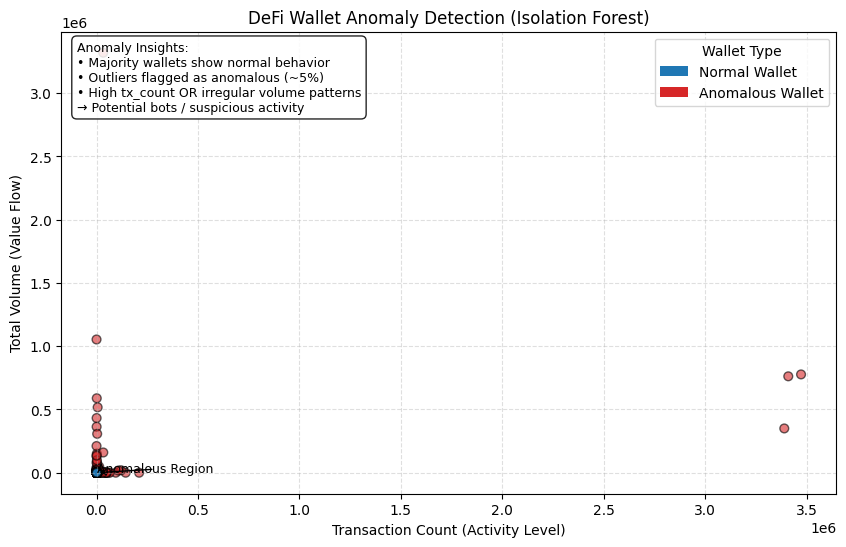

In [31]:
import matplotlib.pyplot as plt
import os
import matplotlib.patches as mpatches

plt.figure(figsize=(10,6))

# Color mapping
color_map = {
    "Normal Wallet": "#1f77b4",      # blue
    "Anomalous Wallet": "#d62728"    # red
}
colors = df['anomaly_label'].map(color_map)

# Scatter
plt.scatter(
    df['tx_count'],
    df['total_volume'],
    c=colors,
    alpha=0.6,
    edgecolors='k',
    s=40
)

# Labels
plt.xlabel("Transaction Count (Activity Level)")
plt.ylabel("Total Volume (Value Flow)")
plt.title("DeFi Wallet Anomaly Detection (Isolation Forest)")

# Grid
plt.grid(True, linestyle='--', alpha=0.4)

# Legend
legend_elements = [
    mpatches.Patch(facecolor="#1f77b4", label="Normal Wallet"),
    mpatches.Patch(facecolor="#d62728", label="Anomalous Wallet")
]
plt.legend(handles=legend_elements, title="Wallet Type")

# 🔥 Insight box (clean + professional)
insight_text = (
    "Anomaly Insights:\n"
    "• Majority wallets show normal behavior\n"
    "• Outliers flagged as anomalous (~5%)\n"
    "• High tx_count OR irregular volume patterns\n"
    "→ Potential bots / suspicious activity"
)

plt.text(
    0.02, 0.98, insight_text,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85)
)

# 🔥 Optional arrow to highlight anomaly region
plt.annotate(
    "Anomalous Region",
    xy=(df['tx_count'].quantile(0.95), df['total_volume'].quantile(0.95)),
    xytext=(df['tx_count'].quantile(0.6), df['total_volume'].quantile(0.9)),
    arrowprops=dict(facecolor='red', arrowstyle='->'),
    fontsize=9
)

# Save
os.makedirs("visuals", exist_ok=True)
plt.savefig("visuals/anomaly_detection.png", dpi=300, bbox_inches='tight')

plt.show()

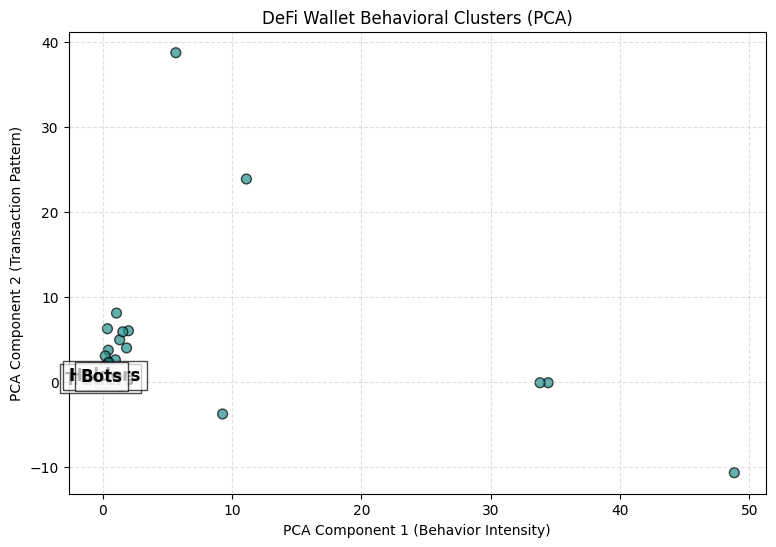

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 🔹 Step 1 — Define cluster names
cluster_names = {
    0: "Traders",
    1: "Holders",
    2: "Bots"
}

# 🔹 Step 2 — Map names to dataframe
df['cluster_name'] = df['cluster'].map(cluster_names)

# 🔹 Step 3 — Create PCA plot
plt.figure(figsize=(9,6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='k',
    s=50
)

# 🔹 Step 4 — Add cluster names at centers
for cluster_id, name in cluster_names.items():
    x_mean = np.mean(X_pca[df['cluster'] == cluster_id, 0])
    y_mean = np.mean(X_pca[df['cluster'] == cluster_id, 1])

    plt.text(
        x_mean,
        y_mean,
        name,
        fontsize=12,
        weight='bold',
        ha='center',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='black')
    )

# 🔹 Labels & styling
plt.xlabel("PCA Component 1 (Behavior Intensity)")
plt.ylabel("PCA Component 2 (Transaction Pattern)")
plt.title("DeFi Wallet Behavioral Clusters (PCA)")

plt.grid(True, linestyle='--', alpha=0.4)

# 🔹 Save figure
os.makedirs("visuals", exist_ok=True)
plt.savefig("visuals/pca_clusters.png", dpi=300, bbox_inches='tight')

plt.show()

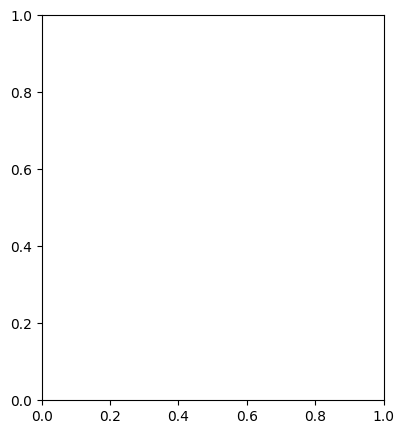

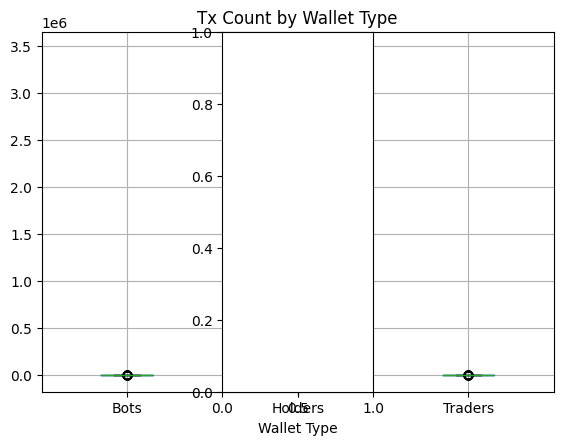

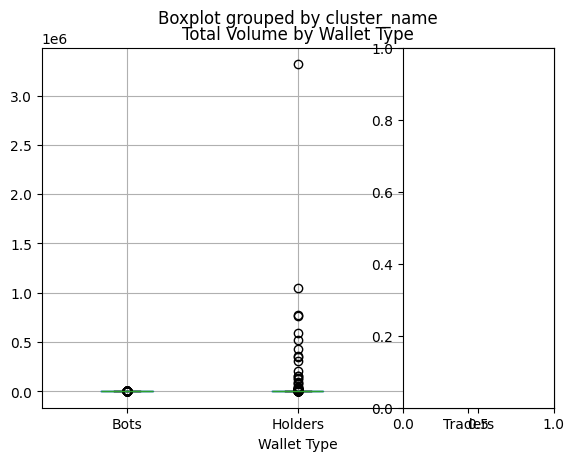

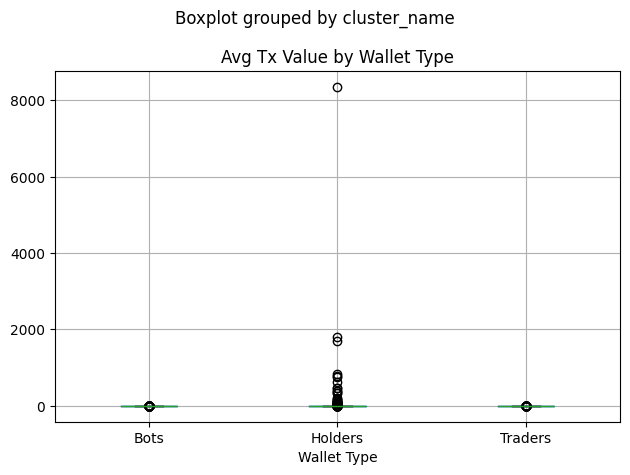

In [33]:
plt.figure(figsize=(15,5))

# Tx Count
plt.subplot(1,3,1)
df.boxplot(column='tx_count', by='cluster_name')
plt.title("Tx Count by Wallet Type")
plt.suptitle("")
plt.xlabel("Wallet Type")

# Total Volume
plt.subplot(1,3,2)
df.boxplot(column='total_volume', by='cluster_name')
plt.title("Total Volume by Wallet Type")
plt.xlabel("Wallet Type")

# Avg Tx Value
plt.subplot(1,3,3)
df.boxplot(column='avg_tx_value', by='cluster_name')
plt.title("Avg Tx Value by Wallet Type")
plt.xlabel("Wallet Type")

plt.tight_layout()
plt.savefig("visuals/boxplot_clusters.png", dpi=300, bbox_inches='tight')
plt.show()

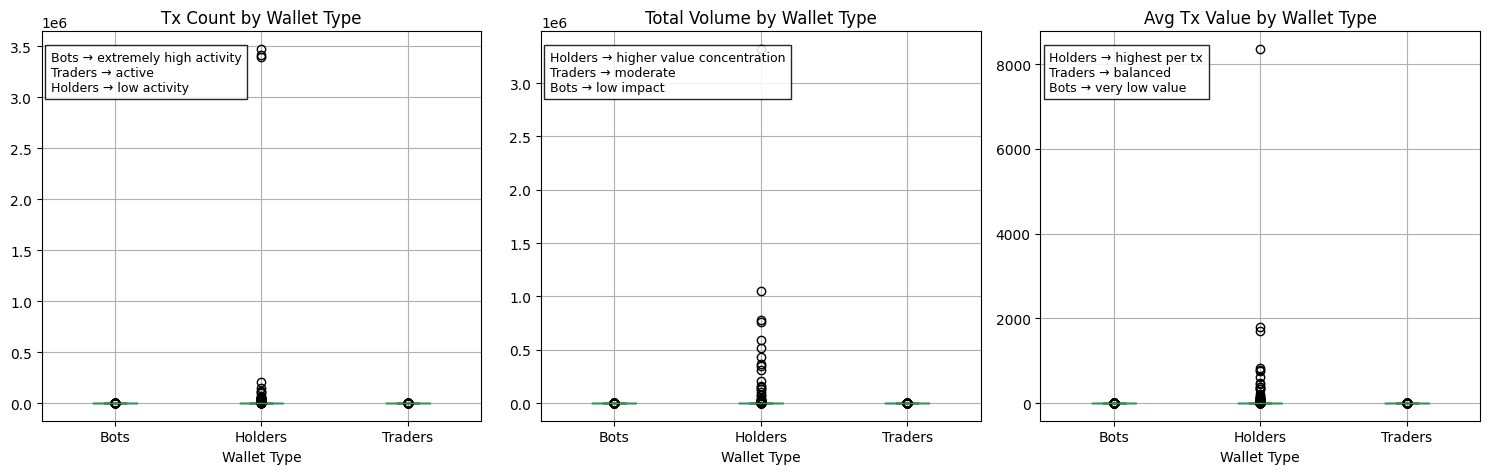

In [34]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(15,5))

# 🔹 Insight text
insights = {
    "tx_count": "Bots → extremely high activity\nTraders → active\nHolders → low activity",
    "total_volume": "Holders → higher value concentration\nTraders → moderate\nBots → low impact",
    "avg_tx_value": "Holders → highest per tx\nTraders → balanced\nBots → very low value"
}

# -----------------------------
# 🔵 Tx Count
# -----------------------------
ax1 = plt.subplot(1,3,1)
df.boxplot(column='tx_count', by='cluster_name', ax=ax1)

ax1.set_title("Tx Count by Wallet Type")
ax1.set_xlabel("Wallet Type")

# Insight box
ax1.text(
    0.02, 0.95,
    insights["tx_count"],
    transform=ax1.transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='black')
)

# -----------------------------
# 🟢 Total Volume
# -----------------------------
ax2 = plt.subplot(1,3,2)
df.boxplot(column='total_volume', by='cluster_name', ax=ax2)

ax2.set_title("Total Volume by Wallet Type")
ax2.set_xlabel("Wallet Type")

ax2.text(
    0.02, 0.95,
    insights["total_volume"],
    transform=ax2.transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='black')
)

# -----------------------------
# 🔴 Avg Tx Value
# -----------------------------
ax3 = plt.subplot(1,3,3)
df.boxplot(column='avg_tx_value', by='cluster_name', ax=ax3)

ax3.set_title("Avg Tx Value by Wallet Type")
ax3.set_xlabel("Wallet Type")

ax3.text(
    0.02, 0.95,
    insights["avg_tx_value"],
    transform=ax3.transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='black')
)

# Remove automatic title
plt.suptitle("")

# Layout + Save
plt.tight_layout()
os.makedirs("visuals", exist_ok=True)
plt.savefig("visuals/boxplot_clusters.png", dpi=300, bbox_inches='tight')

plt.show()

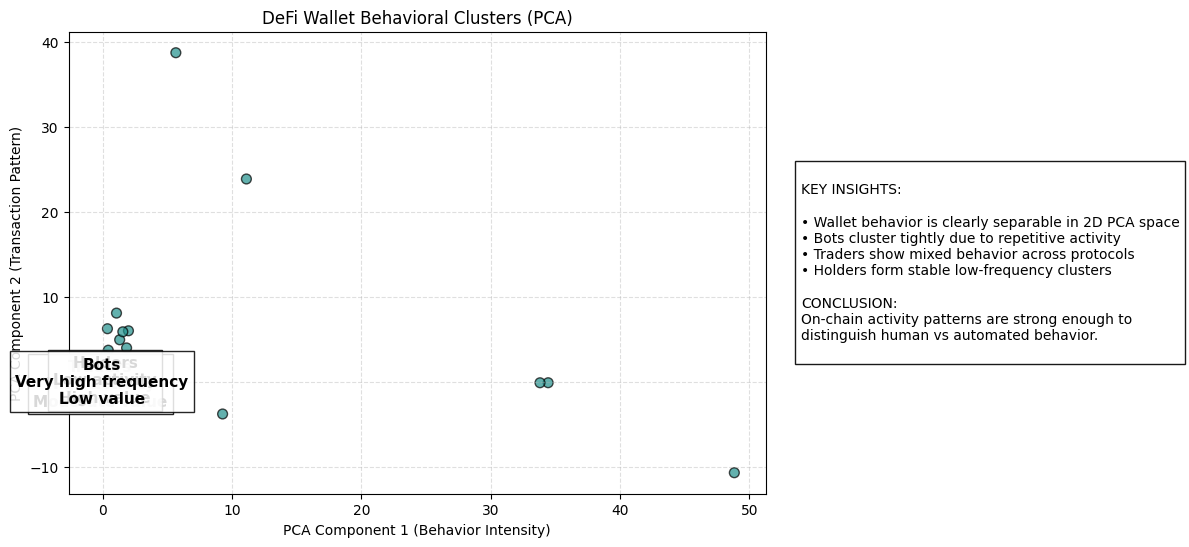

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 🔹 Cluster definitions
cluster_info = {
    0: ("Traders", "High activity\nModerate value"),
    1: ("Holders", "Low activity\nHigh value"),
    2: ("Bots", "Very high frequency\nLow value")
}

df['cluster_name'] = df['cluster'].map({k: v[0] for k, v in cluster_info.items()})

plt.figure(figsize=(9,6))

# Scatter plot
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='k',
    s=50
)

# 🔥 Cluster labels at centers
for cluster_id, (name, desc) in cluster_info.items():
    x_mean = np.mean(X_pca[df['cluster'] == cluster_id, 0])
    y_mean = np.mean(X_pca[df['cluster'] == cluster_id, 1])

    plt.text(
        x_mean,
        y_mean,
        f"{name}\n{desc}",
        fontsize=11,
        weight='bold',
        ha='center',
        va='center',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='black')
    )

# 🔥 INSIGHT BOX (MAIN ADDITION)
insight_text = """
KEY INSIGHTS:

• Wallet behavior is clearly separable in 2D PCA space
• Bots cluster tightly due to repetitive activity
• Traders show mixed behavior across protocols
• Holders form stable low-frequency clusters

CONCLUSION:
On-chain activity patterns are strong enough to
distinguish human vs automated behavior.
"""

plt.gca().text(
    1.05, 0.5,
    insight_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='center',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.9)
)

# Labels
plt.xlabel("PCA Component 1 (Behavior Intensity)")
plt.ylabel("PCA Component 2 (Transaction Pattern)")
plt.title("DeFi Wallet Behavioral Clusters (PCA)")

plt.grid(True, linestyle='--', alpha=0.4)

# Save
os.makedirs("visuals", exist_ok=True)
plt.savefig("visuals/pca_clusters.png", dpi=300, bbox_inches='tight')

plt.show()

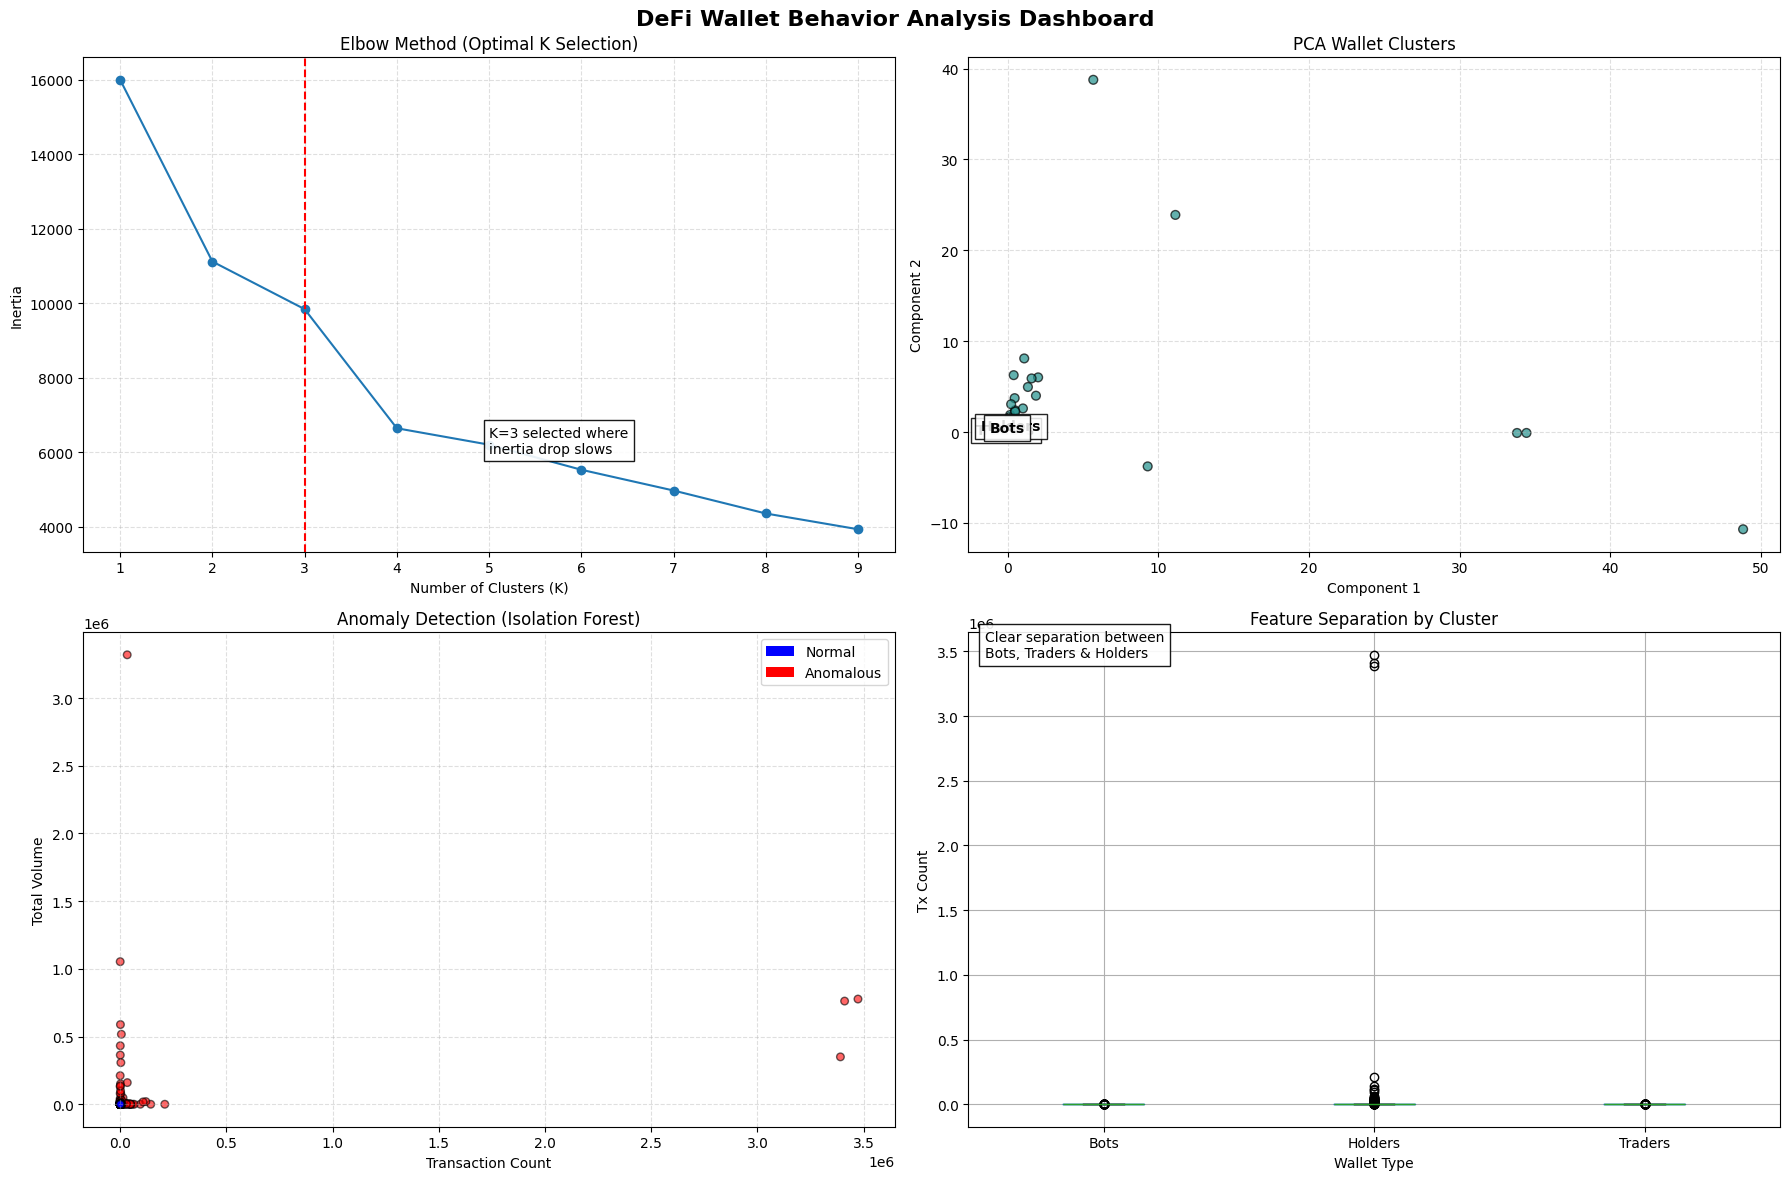

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.patches import Patch

os.makedirs("visuals", exist_ok=True)

fig = plt.figure(figsize=(18,12))

# =========================
# 🔵 1. ELBOW METHOD
# =========================
ax1 = plt.subplot(2,2,1)

ax1.plot(K_range, inertia, marker='o')
ax1.axvline(x=3, linestyle='--', color='red')

ax1.set_title("Elbow Method (Optimal K Selection)")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia")
ax1.grid(True, linestyle='--', alpha=0.4)

ax1.text(
    0.5, 0.2,
    "K=3 selected where\ninertia drop slows",
    transform=ax1.transAxes,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.9)
)

# =========================
# 🟢 2. PCA CLUSTERS
# =========================
ax2 = plt.subplot(2,2,2)

scatter = ax2.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='k',
    s=40
)

cluster_info = {
    0: ("Traders", "Active users"),
    1: ("Holders", "Long-term"),
    2: ("Bots", "Automated")
}

for cluster_id, (name, desc) in cluster_info.items():
    x_mean = np.mean(X_pca[df['cluster'] == cluster_id, 0])
    y_mean = np.mean(X_pca[df['cluster'] == cluster_id, 1])

    ax2.text(
        x_mean, y_mean,
        name,
        fontsize=10,
        weight='bold',
        ha='center',
        bbox=dict(facecolor='white', alpha=0.85)
    )

ax2.set_title("PCA Wallet Clusters")
ax2.set_xlabel("Component 1")
ax2.set_ylabel("Component 2")
ax2.grid(True, linestyle='--', alpha=0.4)

# =========================
# 🔴 3. ANOMALY DETECTION
# =========================
ax3 = plt.subplot(2,2,3)

colors = df['anomaly_label'].map({
    "Normal Wallet": "blue",
    "Anomalous Wallet": "red"
})

ax3.scatter(
    df['tx_count'],
    df['total_volume'],
    c=colors,
    alpha=0.6,
    edgecolors='k',
    s=30
)

ax3.set_title("Anomaly Detection (Isolation Forest)")
ax3.set_xlabel("Transaction Count")
ax3.set_ylabel("Total Volume")

legend_elements = [
    Patch(facecolor='blue', label='Normal'),
    Patch(facecolor='red', label='Anomalous')
]

ax3.legend(handles=legend_elements)
ax3.grid(True, linestyle='--', alpha=0.4)

# =========================
# 📦 4. FEATURE SEPARATION
# =========================
ax4 = plt.subplot(2,2,4)

df.boxplot(column='tx_count', by='cluster_name', ax=ax4)

ax4.set_title("Feature Separation by Cluster")
ax4.set_xlabel("Wallet Type")
ax4.set_ylabel("Tx Count")
plt.suptitle("")

ax4.text(
    0.02, 0.95,
    "Clear separation between\nBots, Traders & Holders",
    transform=ax4.transAxes,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.9)
)

# =========================
# 🎯 GLOBAL TITLE
# =========================
fig.suptitle(
    "DeFi Wallet Behavior Analysis Dashboard",
    fontsize=16,
    weight='bold'
)

plt.tight_layout()

# Save final dashboard
plt.savefig("visuals/deFi_dashboard.png", dpi=300, bbox_inches='tight')

plt.show()

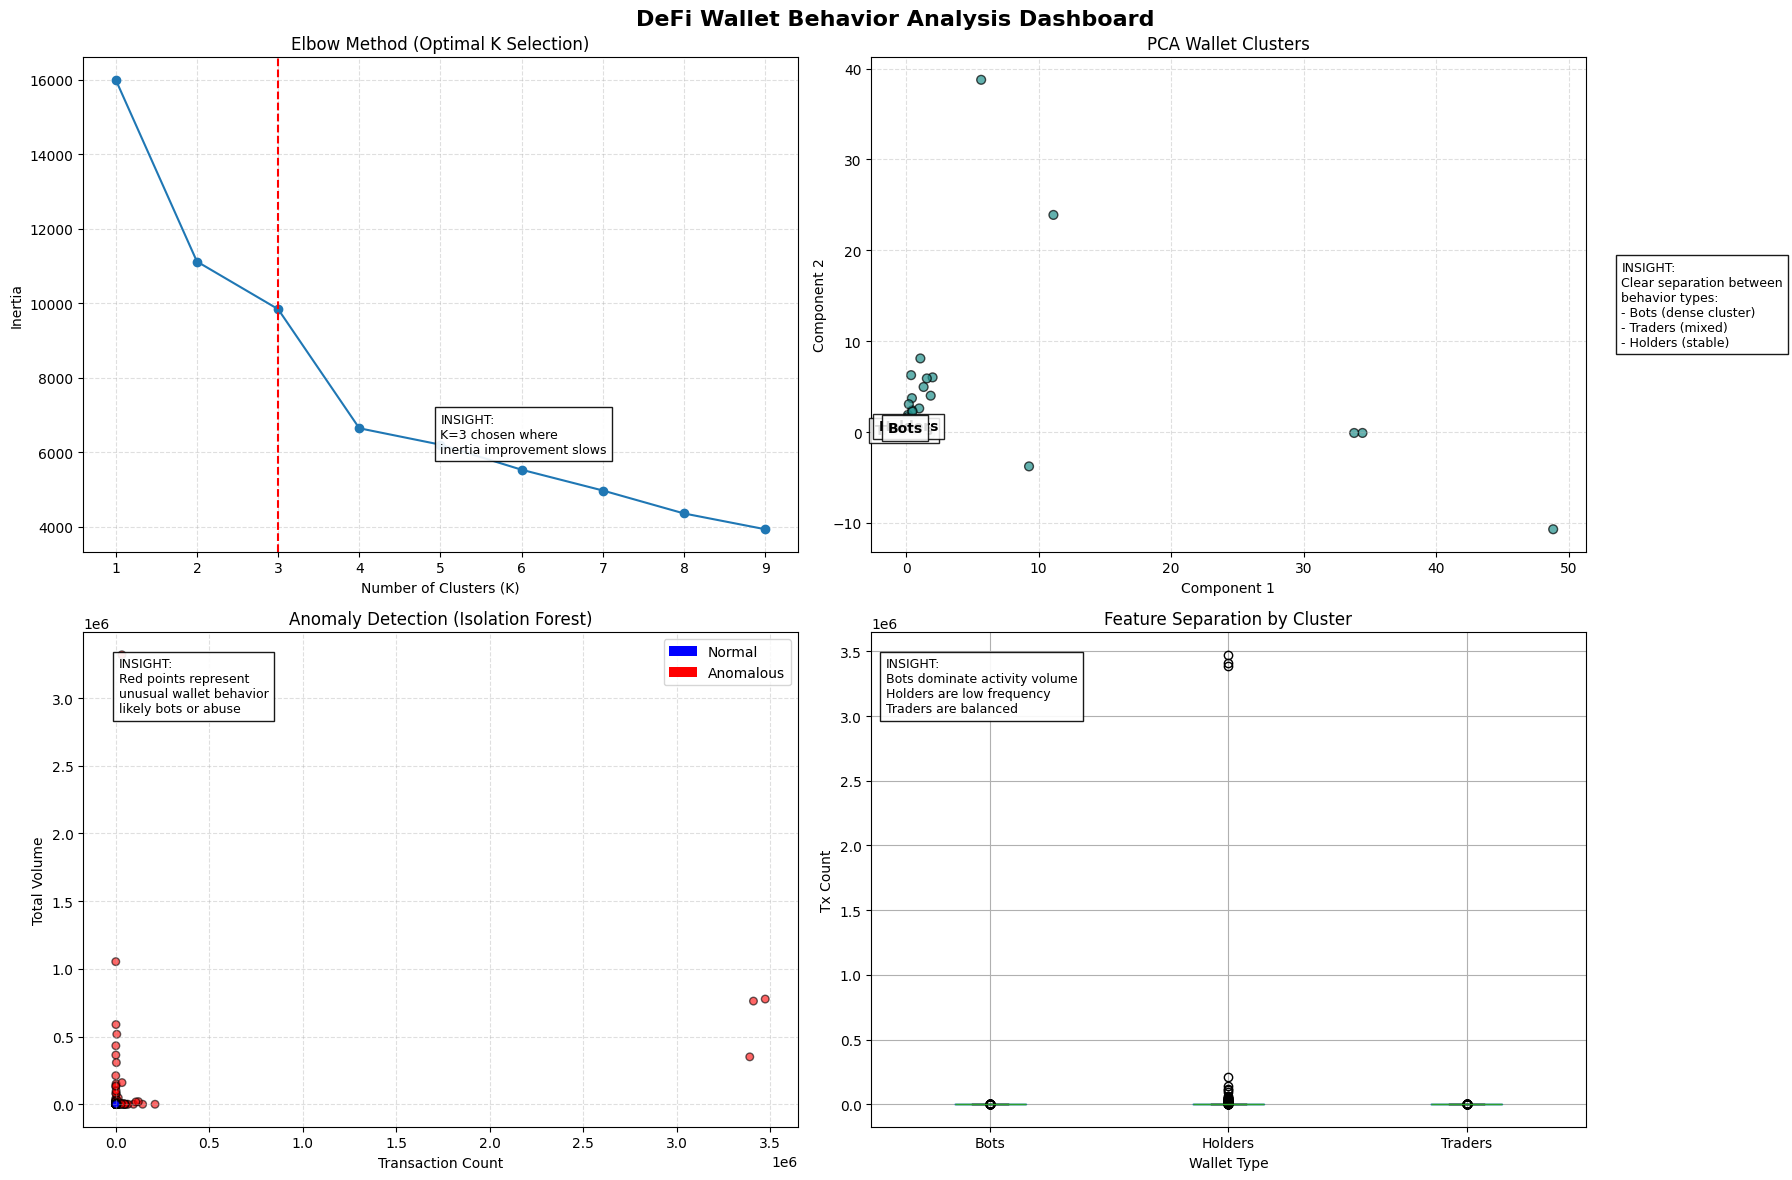

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.patches import Patch

os.makedirs("visuals", exist_ok=True)

fig = plt.figure(figsize=(18,12))

# =========================
# 🔵 1. ELBOW METHOD
# =========================
ax1 = plt.subplot(2,2,1)

ax1.plot(K_range, inertia, marker='o')
ax1.axvline(x=3, linestyle='--', color='red')

ax1.set_title("Elbow Method (Optimal K Selection)")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia")
ax1.grid(True, linestyle='--', alpha=0.4)

ax1.text(
    0.5, 0.2,
    "INSIGHT:\nK=3 chosen where\ninertia improvement slows",
    transform=ax1.transAxes,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.9),
    fontsize=9
)

# =========================
# 🟢 2. PCA CLUSTERS
# =========================
ax2 = plt.subplot(2,2,2)

ax2.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='k',
    s=40
)

cluster_info = {
    0: ("Traders", "High activity\nModerate value"),
    1: ("Holders", "Low activity\nHigh value"),
    2: ("Bots", "Very high frequency\nLow value")
}

for cluster_id, (name, desc) in cluster_info.items():
    x_mean = np.mean(X_pca[df['cluster'] == cluster_id, 0])
    y_mean = np.mean(X_pca[df['cluster'] == cluster_id, 1])

    ax2.text(
        x_mean,
        y_mean,
        name,
        fontsize=10,
        weight='bold',
        ha='center',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='black')
    )

ax2.set_title("PCA Wallet Clusters")
ax2.set_xlabel("Component 1")
ax2.set_ylabel("Component 2")
ax2.grid(True, linestyle='--', alpha=0.4)

ax2.text(
    1.05, 0.5,
    "INSIGHT:\nClear separation between\nbehavior types:\n- Bots (dense cluster)\n- Traders (mixed)\n- Holders (stable)",
    transform=ax2.transAxes,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.9),
    fontsize=9,
    va='center'
)

# =========================
# 🔴 3. ANOMALY DETECTION
# =========================
ax3 = plt.subplot(2,2,3)

colors = df['anomaly_label'].map({
    "Normal Wallet": "blue",
    "Anomalous Wallet": "red"
})

ax3.scatter(
    df['tx_count'],
    df['total_volume'],
    c=colors,
    alpha=0.6,
    edgecolors='k',
    s=30
)

ax3.set_title("Anomaly Detection (Isolation Forest)")
ax3.set_xlabel("Transaction Count")
ax3.set_ylabel("Total Volume")

legend_elements = [
    Patch(facecolor='blue', label='Normal'),
    Patch(facecolor='red', label='Anomalous')
]

ax3.legend(handles=legend_elements)
ax3.grid(True, linestyle='--', alpha=0.4)

ax3.text(
    0.05, 0.95,
    "INSIGHT:\nRed points represent\nunusual wallet behavior\nlikely bots or abuse",
    transform=ax3.transAxes,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.9),
    fontsize=9,
    va='top'
)

# =========================
# 📦 4. FEATURE SEPARATION
# =========================
ax4 = plt.subplot(2,2,4)

df.boxplot(column='tx_count', by='cluster_name', ax=ax4)

ax4.set_title("Feature Separation by Cluster")
ax4.set_xlabel("Wallet Type")
ax4.set_ylabel("Tx Count")
plt.suptitle("")

ax4.text(
    0.02, 0.95,
    "INSIGHT:\nBots dominate activity volume\nHolders are low frequency\nTraders are balanced",
    transform=ax4.transAxes,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.9),
    fontsize=9,
    va='top'
)

# =========================
# 🎯 GLOBAL TITLE
# =========================
fig.suptitle(
    "DeFi Wallet Behavior Analysis Dashboard",
    fontsize=16,
    weight='bold'
)

plt.tight_layout()

plt.savefig("visuals/deFi_dashboard.png", dpi=300, bbox_inches='tight')

plt.show()